# Nigerian Real Estate — Multi-Dataset ML Pipeline
**Regression**: predict property sale `price`  
**Classification**: predict `property_type` (detached / flat / semi_detached / terrace / bungalow)

In [ ]:
import joblib
import numpy as np

# Load everything once at app startup
encoders   = joblib.load('model/label_encoders.pkl')
reg_model  = joblib.load('model/gradboost_rental_price_regressor.pkl')
type_model = joblib.load('model/xgboost_property_type_classifier.pkl')
tier_model = joblib.load('model/xgboost_price_tier_classifier.pkl')

In [ ]:
# ── Core ──────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

# ── Preprocessing & Metrics ───────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error, root_mean_squared_error, r2_score,
    accuracy_score, classification_report
)

# ── Models ────────────────────────────────────────────────────────────────────
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier

# ── Explainability ────────────────────────────────────────────────────────────
import shap

print('All packages imported successfully.')

All packages imported successfully.


## 1. Load & Merge Datasets from HuggingFace

| Dataset | Schema | Role |
|---|---|---|
| `location_hotspots` | id, date, city, value, category | City location-quality score |
| `neighborhood_amenities` | id, date, city, value, category | Neighbourhood amenity index |
| `property_inspections` | id, date, city, value, category | Inspection grade index |
| `title_registrations` | id, date, city, value, category | Title/legal value index |
| `service_charges` | id, date, city, value, category | Service-charge level index |
| `construction_costs` | id, date, city, value, category | Construction cost index |
| `land_disputes` | id, date, city, value, category | Land dispute risk index |
| `electricity_access` | lga_name, state_name, year, access_pct … | State electricity access % |
| `rental_listings` | listing_id, city, property_type, bedrooms … | Rental pricing context |
| `residential_listings` | listing_id, city, property_type, price … | **Primary base table** |

In [ ]:
BASE = 'hf://datasets/electricsheepafrica/'

# 1a. Primary base: residential listings (richest feature set)
residential = pd.read_parquet(
    BASE + 'nigerian_realestate_residential_listings/nigerian_realestate_residential_listings.parquet'
)
print(f'residential_listings  : {residential.shape}')

# 1b. Rental listings for rental-yield context
rental = pd.read_parquet(
    BASE + 'nigerian_realestate_rental_listings/nigerian_realestate_rental_listings.parquet'
)
print(f'rental_listings       : {rental.shape}')

# 1c. Seven uniform-schema index datasets (city / value / category)
index_datasets = {
    'hotspot':      BASE + 'nigerian_realestate_location_hotspots/nigerian_realestate_location_hotspots.parquet',
    'amenity':      BASE + 'nigerian_realestate_neighborhood_amenities/nigerian_realestate_neighborhood_amenities.parquet',
    'inspection':   BASE + 'nigerian_realestate_property_inspections/nigerian_realestate_property_inspections.parquet',
    'title':        BASE + 'nigerian_realestate_title_registrations/nigerian_realestate_title_registrations.parquet',
    'service':      BASE + 'nigerian_realestate_service_charges/nigerian_realestate_service_charges.parquet',
    'construction': BASE + 'nigerian_realestate_construction_costs/nigerian_realestate_construction_costs.parquet',
    'land_dispute': BASE + 'nigerian_realestate_land_disputes/nigerian_realestate_land_disputes.parquet',
}

index_dfs = {}
for name, path in index_datasets.items():
    index_dfs[name] = pd.read_parquet(path)
    print(f'{name:12s} index  : {index_dfs[name].shape}')

# 1d. Electricity access (state / LGA level)
elec_raw = pd.read_parquet(
    'hf://datasets/electricsheepafrica/nigerian_electricity_lga_electricity_access/nigerian_electricity_lga_electricity_access.parquet'
)
print(f'electricity_access    : {elec_raw.shape}')

residential_listings  : (300000, 12)
rental_listings       : (250000, 10)
hotspot      index  : (50000, 5)
amenity      index  : (80000, 5)
inspection   index  : (90000, 5)
title        index  : (100000, 5)
service      index  : (120000, 5)
construction index  : (70000, 5)
land_dispute index  : (50000, 5)
electricity_access    : (4734, 6)


In [ ]:
# 1e. Build city-level aggregates from each index dataset
# Each produces: {source}_median_value, {source}_mean_value, {source}_grade per city
# The loop covers all 7 sources: hotspot, amenity, inspection, title, service,
# construction, land_dispute

city_features = None

for name, df in index_dfs.items():
    agg = (
        df.groupby('city')['value']
        .agg(median='median', mean='mean')
        .rename(columns={'median': f'{name}_median_value', 'mean': f'{name}_mean_value'})
        .reset_index()
    )
    dom_cat = (
        df.groupby(['city', 'category'])
        .size()
        .reset_index(name='cnt')
        .sort_values('cnt', ascending=False)
        .drop_duplicates('city')
        .rename(columns={'category': f'{name}_grade'})
        [['city', f'{name}_grade']]
    )
    agg = agg.merge(dom_cat, on='city', how='left')
    city_features = agg if city_features is None else city_features.merge(agg, on='city', how='outer')

print('City-level feature columns:', city_features.columns.tolist())
city_features.head()

City-level feature columns: ['city', 'hotspot_median_value', 'hotspot_mean_value', 'hotspot_grade', 'amenity_median_value', 'amenity_mean_value', 'amenity_grade', 'inspection_median_value', 'inspection_mean_value', 'inspection_grade', 'title_median_value', 'title_mean_value', 'title_grade', 'service_median_value', 'service_mean_value', 'service_grade', 'construction_median_value', 'construction_mean_value', 'construction_grade', 'land_dispute_median_value', 'land_dispute_mean_value', 'land_dispute_grade']


,city,hotspot_median_value,hotspot_mean_value,hotspot_grade,amenity_median_value,amenity_mean_value,amenity_grade,inspection_median_value,inspection_mean_value,inspection_grade,...,title_grade,service_median_value,service_mean_value,service_grade,construction_median_value,construction_mean_value,construction_grade,land_dispute_median_value,land_dispute_mean_value,land_dispute_grade
0,Abuja,24868841.5,2.521437e+07,A,25048513.0,2.545862e+07,A,25028525.0,2.543928e+07,A,...,A,24994935.0,2.536010e+07,A,25103241.0,2.539239e+07,A,25148821.0,2.548934e+07,A
1,Benin City,24636089.0,2.516511e+07,A,25559335.0,2.592068e+07,A,25025365.0,2.529941e+07,A,...,A,25117099.0,2.526586e+07,A,25088575.0,2.551250e+07,A,25307906.0,2.527195e+07,A
2,Calabar,25847540.0,2.592895e+07,A,24644232.0,2.498752e+07,A,25232579.0,2.579834e+07,A,...,A,25038495.5,2.520547e+07,A,25562386.0,2.557219e+07,A,25150999.5,2.527166e+07,A
3,Enugu,25099838.0,2.548617e+07,A,24778893.0,2.522318e+07,A,24683737.0,2.500518e+07,A,...,A,25149324.0,2.542965e+07,A,25208352.5,2.538290e+07,A,25319339.0,2.546678e+07,A
4,Ibadan,24274878.0,2.456844e+07,A,24950038.0,2.525535e+07,A,24907770.5,2.538247e+07,A,...,A,25110314.0,2.537806e+07,A,25142140.5,2.535471e+07,A,24914657.5,2.513489e+07,A


In [ ]:
# 1f. Aggregate electricity access from state -> city level
# Map each Nigerian state to the corresponding city in our dataset
STATE_TO_CITY = {
    'FCT':         'Abuja',
    'Lagos':       'Lagos',
    'Kano':        'Kano',
    'Oyo':         'Ibadan',
    'Rivers':      'Port Harcourt',
    'Enugu':       'Enugu',
    'Cross River': 'Calabar',
    'Akwa Ibom':   'Uyo',
    'Imo':         'Owerri',
    'Edo':         'Benin City',
}

elec_mapped = elec_raw[elec_raw['state_name'].isin(STATE_TO_CITY)].copy()
elec_mapped['city'] = elec_mapped['state_name'].map(STATE_TO_CITY)

# Use the most recent year's LGA figures, then aggregate to city level
latest_year = elec_mapped['year'].max()
elec_latest = elec_mapped[elec_mapped['year'] == latest_year]

elec_agg = (
    elec_latest
    .groupby('city')
    .agg(
        elec_access_pct_mean=('access_pct', 'mean'),
        elec_access_pct_min=('access_pct', 'min'),
        elec_population_total=('population', 'sum'),
        elec_electrified_total=('electrified_pop', 'sum'),
    )
    .reset_index()
)
print(f'Electricity city aggregation (year={latest_year}): {elec_agg.shape}')
elec_agg

Electricity city aggregation (year=2023): (9, 5)


,city,elec_access_pct_mean,elec_access_pct_min,elec_population_total,elec_electrified_total
0,Benin City,69.744444,61.5,8597335,5986290
1,Calabar,54.883333,48.8,8049346,4358798
2,Enugu,55.341176,47.6,7243279,4096678
3,Ibadan,86.518182,73.8,15374812,13173361
4,Kano,84.629545,72.6,17861229,15029537
5,Lagos,93.845000,84.8,17230908,16165395
6,Owerri,59.270370,51.7,11369700,6710139
7,Port Harcourt,91.065217,78.5,11013049,9962758
8,Uyo,65.167742,54.2,12559144,8330892


In [ ]:
# 1g. Aggregate rental context by city + property_type + bedrooms
rental_agg = (
    rental
    .groupby(['city', 'property_type', 'bedrooms'])
    .agg(
        rental_annual_median=('annual_rent', 'median'),
        rental_monthly_median=('monthly_rent', 'median'),
        rental_count=('listing_id', 'count'),
    )
    .reset_index()
)
print(f'Rental aggregation rows: {len(rental_agg):,}')
rental_agg.head()

Rental aggregation rows: 120


,city,property_type,bedrooms,rental_annual_median,rental_monthly_median,rental_count
0,Abuja,bungalow,2,2249416.0,187451.0,1271
1,Abuja,bungalow,3,2166932.0,180577.0,1247
2,Abuja,detached,3,2177561.5,181463.0,2452
3,Abuja,detached,4,2224261.5,185355.0,2552
4,Abuja,detached,5,2177471.5,181455.5,2538


In [ ]:
# 1h. Merge everything into one flat table
#  Base  : residential_listings           (300k rows)
#  + left: rental_agg    on city + property_type + bedrooms
#  + left: city_features on city  (7 index dataset aggregates)
#  + left: elec_agg      on city  (electricity access)

df = (
    residential
    .merge(rental_agg,    on=['city', 'property_type', 'bedrooms'], how='left')
    .merge(city_features, on='city',                                how='left')
    .merge(elec_agg,      on='city',                                how='left')
)

print(f'Merged dataset shape : {df.shape}')
null_counts = df.isnull().sum()
print(f'Null counts (non-zero):\n{null_counts[null_counts > 0]}')
df.head(3)

Merged dataset shape : (300000, 40)
Null counts (non-zero):
elec_access_pct_mean      59839
elec_access_pct_min       59839
elec_population_total     59839
elec_electrified_total    59839
dtype: int64


,listing_id,city,neighborhood,property_type,bedrooms,bathrooms,size_sqm,age_years,price,price_per_sqm,...,construction_median_value,construction_mean_value,construction_grade,land_dispute_median_value,land_dispute_mean_value,land_dispute_grade,elec_access_pct_mean,elec_access_pct_min,elec_population_total,elec_electrified_total
0,PROP-0947409,Lagos,Isolo,detached,3,2,434,8,43536798,100315.20,...,25109315.5,2.547070e+07,A,25169431.0,2.543884e+07,A,93.845,84.8,17230908.0,16165395.0
1,PROP-0662717,Lagos,Surulere,flat,1,1,101,27,13012328,128834.93,...,25109315.5,2.547070e+07,A,25169431.0,2.543884e+07,A,93.845,84.8,17230908.0,16165395.0
2,PROP-0703058,Abuja,Karu,flat,3,2,183,28,19237848,105124.85,...,25103241.0,2.539239e+07,A,25148821.0,2.548934e+07,A,NaN,NaN,NaN,NaN


## 2. Exploratory Data Analysis

In [ ]:
print('=== Schema ===')
print(df.dtypes.to_string())
print(f'\nRows: {len(df):,}  |  Columns: {df.shape[1]}')
print('\n=== Price Stats (₦) ===')
print(df['price'].describe().apply(lambda x: f'{x:,.0f}'))
print('\n=== Property Type Distribution ===')
print(df['property_type'].value_counts())

=== Schema ===
listing_id                       str
city                             str
neighborhood                     str
property_type                    str
bedrooms                       int64
bathrooms                      int64
size_sqm                       int64
age_years                      int64
price                          int64
price_per_sqm                float64
amenities                        str
listing_date                     str
rental_annual_median         float64
rental_monthly_median        float64
rental_count                   int64
hotspot_median_value         float64
hotspot_mean_value           float64
hotspot_grade                    str
amenity_median_value         float64
amenity_mean_value           float64
amenity_grade                    str
inspection_median_value      float64
inspection_mean_value        float64
inspection_grade                 str
title_median_value           float64
title_mean_value             float64
title_grade            

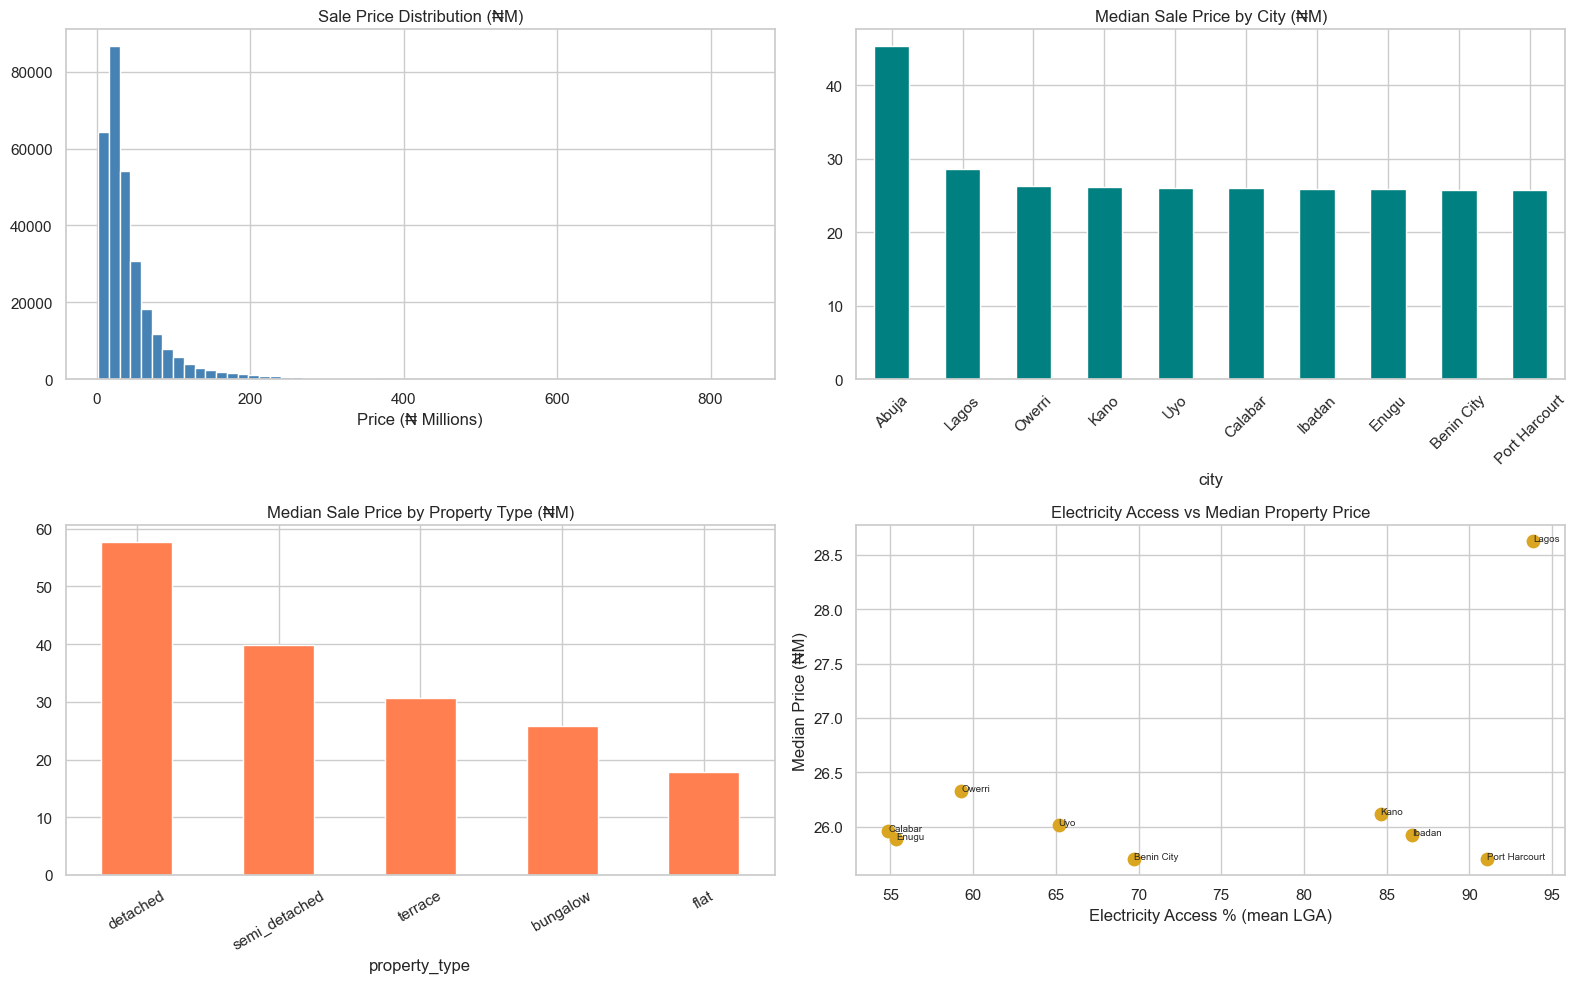

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].hist(df['price'] / 1e6, bins=60, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Sale Price Distribution (₦M)')
axes[0, 0].set_xlabel('Price (₦ Millions)')

city_med = df.groupby('city')['price'].median().sort_values(ascending=False) / 1e6
city_med.plot(kind='bar', ax=axes[0, 1], color='teal', edgecolor='white')
axes[0, 1].set_title('Median Sale Price by City (₦M)')
axes[0, 1].tick_params(axis='x', rotation=45)

pt_med = df.groupby('property_type')['price'].median().sort_values(ascending=False) / 1e6
pt_med.plot(kind='bar', ax=axes[1, 0], color='coral', edgecolor='white')
axes[1, 0].set_title('Median Sale Price by Property Type (₦M)')
axes[1, 0].tick_params(axis='x', rotation=30)

# Electricity access vs median price scatter
city_elec = df.groupby('city').agg(
    median_price=('price', 'median'),
    elec_pct=('elec_access_pct_mean', 'first')
).reset_index()
axes[1, 1].scatter(city_elec['elec_pct'], city_elec['median_price'] / 1e6,
                   color='goldenrod', s=80, zorder=3)
for _, row in city_elec.iterrows():
    axes[1, 1].annotate(row['city'], (row['elec_pct'], row['median_price'] / 1e6),
                        fontsize=7, ha='left')
axes[1, 1].set_xlabel('Electricity Access % (mean LGA)')
axes[1, 1].set_ylabel('Median Price (₦M)')
axes[1, 1].set_title('Electricity Access vs Median Property Price')

plt.tight_layout()
plt.show()

## 3. Feature Engineering & Preprocessing

In [ ]:
import os
data = df.copy()

# ── Date features ──────────────────────────────────────────────────────────────
data['listing_date']    = pd.to_datetime(data['listing_date'])
data['listing_year']    = data['listing_date'].dt.year
data['listing_month']   = data['listing_date'].dt.month
data['listing_quarter'] = data['listing_date'].dt.quarter

# ── Amenity count from comma-separated string ──────────────────────────────────
data['amenity_count'] = (
    data['amenities']
    .fillna('')
    .apply(lambda x: len([a.strip() for a in x.split(',') if a.strip()]))
)

# ── Fill rental nulls with city-level medians ──────────────────────────────────
for col in ['rental_annual_median', 'rental_monthly_median', 'rental_count']:
    data[col] = data.groupby('city')[col].transform(lambda x: x.fillna(x.median()))

# ── Fill electricity nulls with global medians ─────────────────────────────────
for col in ['elec_access_pct_mean', 'elec_access_pct_min',
            'elec_population_total', 'elec_electrified_total']:
    data[col] = data[col].fillna(data[col].median())

# ── Encode categoricals ────────────────────────────────────────────────────────
encoders = {}
for col in ['city', 'neighborhood', 'property_type',
            'hotspot_grade', 'amenity_grade', 'inspection_grade',
            'title_grade', 'service_grade',
            'construction_grade', 'land_dispute_grade']:
    le = LabelEncoder()
    data[f'{col}_enc'] = le.fit_transform(data[col].astype(str))
    encoders[col] = le

# ── Derive price tier from rental_annual_median (3 balanced classes) ───────────
low_cut  = data['rental_annual_median'].quantile(0.33)
high_cut = data['rental_annual_median'].quantile(0.67)
data['price_tier'] = pd.cut(
    data['rental_annual_median'],
    bins=[-np.inf, low_cut, high_cut, np.inf],
    labels=['Low', 'Mid', 'High']
)
tier_enc = LabelEncoder()
data['price_tier_enc'] = tier_enc.fit_transform(data['price_tier'].astype(str))
encoders['price_tier'] = tier_enc

os.makedirs('../model', exist_ok=True)
joblib.dump(encoders, '../model/label_encoders.pkl')

# ── Feature sets ───────────────────────────────────────────────────────────────
# REGRESSION: location + neighbourhood amenities + electricity ONLY
REG_FEATURES = [
    # Location
    'city_enc', 'neighborhood_enc',
    'listing_year', 'listing_month', 'listing_quarter',
    # Neighbourhood amenities
    'amenity_count',
    'amenity_median_value', 'amenity_mean_value', 'amenity_grade_enc',
    # Electricity access
    'elec_access_pct_mean', 'elec_access_pct_min',
    'elec_population_total', 'elec_electrified_total',
]

# CLASSIFICATION: ALL features (exclude both clf targets to avoid leakage)
CLF_FEATURES = [
    'bedrooms', 'bathrooms', 'size_sqm', 'age_years', 'price_per_sqm',
    'amenity_count',
    'city_enc', 'neighborhood_enc',
    'rental_annual_median', 'rental_monthly_median', 'rental_count',
    'hotspot_median_value',      'hotspot_mean_value',      'hotspot_grade_enc',
    'amenity_median_value',      'amenity_mean_value',      'amenity_grade_enc',
    'inspection_median_value',   'inspection_mean_value',   'inspection_grade_enc',
    'title_median_value',        'title_mean_value',        'title_grade_enc',
    'service_median_value',      'service_mean_value',      'service_grade_enc',
    'construction_median_value', 'construction_mean_value', 'construction_grade_enc',
    'land_dispute_median_value', 'land_dispute_mean_value', 'land_dispute_grade_enc',
    'elec_access_pct_mean', 'elec_access_pct_min',
    'elec_population_total', 'elec_electrified_total',
    'listing_year', 'listing_month', 'listing_quarter',
]

REGRESSION_TARGET = 'rental_annual_median'  # annual rent ₦/year
TYPE_CLF_TARGET   = 'property_type_enc'     # 5 classes
TIER_CLF_TARGET   = 'price_tier_enc'        # 3 classes: Low / Mid / High

data = data.dropna(subset=REG_FEATURES + CLF_FEATURES + [REGRESSION_TARGET])

print(f'Final dataset        : {data.shape[0]:,} rows')
print(f'REG_FEATURES         : {len(REG_FEATURES)} features')
print(f'CLF_FEATURES         : {len(CLF_FEATURES)} features')
print(f'Regression target    : {REGRESSION_TARGET}')
print(f'Property type classes: {encoders["property_type"].classes_.tolist()}')
print(f'Price tier classes   : {encoders["price_tier"].classes_.tolist()}')
print(f'\nPrice tier distribution:\n{data["price_tier"].value_counts().sort_index()}')


Final dataset        : 300,000 rows
REG_FEATURES         : 13 features
CLF_FEATURES         : 39 features
Regression target    : rental_annual_median
Property type classes: ['bungalow', 'detached', 'flat', 'semi_detached', 'terrace']
Price tier classes   : ['High', 'Low', 'Mid']

Price tier distribution:
price_tier
Low     100832
Mid     111702
High     87466
Name: count, dtype: int64


## 4. Train / Test Split

In [ ]:
X_reg = data[REG_FEATURES]
X_clf = data[CLF_FEATURES]
y_reg  = data[REGRESSION_TARGET]
y_type = data[TYPE_CLF_TARGET]
y_tier = data[TIER_CLF_TARGET]

# Single index-based split — ensures identical row alignment across all arrays
idx_train, idx_test = train_test_split(data.index, test_size=0.2, random_state=42)

X_reg_train,  X_reg_test  = X_reg.loc[idx_train],  X_reg.loc[idx_test]
X_clf_train,  X_clf_test  = X_clf.loc[idx_train],  X_clf.loc[idx_test]
y_reg_train,  y_reg_test  = y_reg.loc[idx_train],  y_reg.loc[idx_test]
y_type_train, y_type_test = y_type.loc[idx_train], y_type.loc[idx_test]
y_tier_train, y_tier_test = y_tier.loc[idx_train], y_tier.loc[idx_test]

print(f'Train : {len(idx_train):,} rows')
print(f'Test  : {len(idx_test):,} rows')
print(f'X_reg shape  : {X_reg_train.shape}  →  {X_reg_test.shape}')
print(f'X_clf shape  : {X_clf_train.shape}  →  {X_clf_test.shape}')


Train : 240,000 rows
Test  : 60,000 rows
X_reg shape  : (240000, 13)  →  (60000, 13)
X_clf shape  : (240000, 39)  →  (60000, 39)


## 5. Model Training
### 5a. Regression — Predict Annual Rental Cost
**Target**: `rental_annual_median` (₦/year)  
**Features**: location (`city`, `neighborhood`) + neighbourhood amenities + electricity access


In [ ]:
reg_models = {
    'Ridge':        Ridge(),
    'RandomForest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'GradBoost':    GradientBoostingRegressor(n_estimators=200, random_state=42),
    'XGBoost':      XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42,
                                  tree_method='hist', verbosity=0),
    'LightGBM':     LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42,
                                   n_jobs=-1, verbose=-1),
}

trained_reg = {}
for name, model in reg_models.items():
    model.fit(X_reg_train, y_reg_train)
    trained_reg[name] = model
    print(f'{name:15s} — trained  [target: annual rental cost, features: location + amenity + electricity]')


Ridge           — trained  [target: annual rental cost, features: location + amenity + electricity]
RandomForest    — trained  [target: annual rental cost, features: location + amenity + electricity]
GradBoost       — trained  [target: annual rental cost, features: location + amenity + electricity]
XGBoost         — trained  [target: annual rental cost, features: location + amenity + electricity]
LightGBM        — trained  [target: annual rental cost, features: location + amenity + electricity]


### 5b. Classification — Property Type & Price Tier
**Task A**: Predict `property_type` (5 classes: detached / flat / semi_detached / terrace / bungalow)  
**Task B**: Predict `price_tier` (3 classes: Low / Mid / High — derived from 33rd/67th rental percentiles)  
**Features**: All 41 features (full dataset)


In [ ]:
# ── Task A: Property Type Classification (5 classes) ──────────────────────────
type_models = {
    'XGBoost':  XGBClassifier(n_estimators=300, learning_rate=0.05, random_state=42,
                               tree_method='hist', verbosity=0, eval_metric='mlogloss'),
    'LightGBM': LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=42,
                                n_jobs=-1, verbose=-1),
}
trained_type = {}
for name, model in type_models.items():
    model.fit(X_clf_train, y_type_train)
    trained_type[name] = model
    print(f'{name:15s} — trained  [target: property_type — 5 classes]')

# ── Task B: Price Tier Classification (Low / Mid / High) ──────────────────────
tier_models = {
    'XGBoost':  XGBClassifier(n_estimators=300, learning_rate=0.05, random_state=42,
                               tree_method='hist', verbosity=0, eval_metric='mlogloss'),
    'LightGBM': LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=42,
                                n_jobs=-1, verbose=-1),
}
trained_tier = {}
for name, model in tier_models.items():
    model.fit(X_clf_train, y_tier_train)
    trained_tier[name] = model
    print(f'{name:15s} — trained  [target: price_tier   — 3 classes: Low/Mid/High]')


XGBoost         — trained  [target: property_type — 5 classes]
LightGBM        — trained  [target: property_type — 5 classes]
XGBoost         — trained  [target: price_tier   — 3 classes: Low/Mid/High]
LightGBM        — trained  [target: price_tier   — 3 classes: Low/Mid/High]


## 6. Evaluation
### 6a. Regression Metrics

In [ ]:
reg_results = []
for name, model in trained_reg.items():
    preds = model.predict(X_reg_test)
    reg_results.append({
        'Model':     name,
        'MAE (₦K)':  round(mean_absolute_error(y_reg_test, preds) / 1_000, 1),
        'RMSE (₦K)': round(root_mean_squared_error(y_reg_test, preds) / 1_000, 1),
        'R²':        round(r2_score(y_reg_test, preds), 4),
    })

reg_df = pd.DataFrame(reg_results).sort_values('RMSE (₦K)').reset_index(drop=True)
print('── Regression: Predict Annual Rental Cost (₦/year) ──')
print(reg_df.to_string(index=False))

best_reg_name  = reg_df.iloc[0]['Model']
best_reg_model = trained_reg[best_reg_name]
print(f'\nBest regression model: {best_reg_name}')


── Regression: Predict Annual Rental Cost (₦/year) ──
       Model  MAE (₦K)  RMSE (₦K)     R²
   GradBoost      23.1       33.9 0.9798
     XGBoost      23.2       33.9 0.9798
    LightGBM      23.2       33.9 0.9798
RandomForest      24.3       34.7 0.9788
       Ridge      43.5       59.2 0.9383

Best regression model: GradBoost


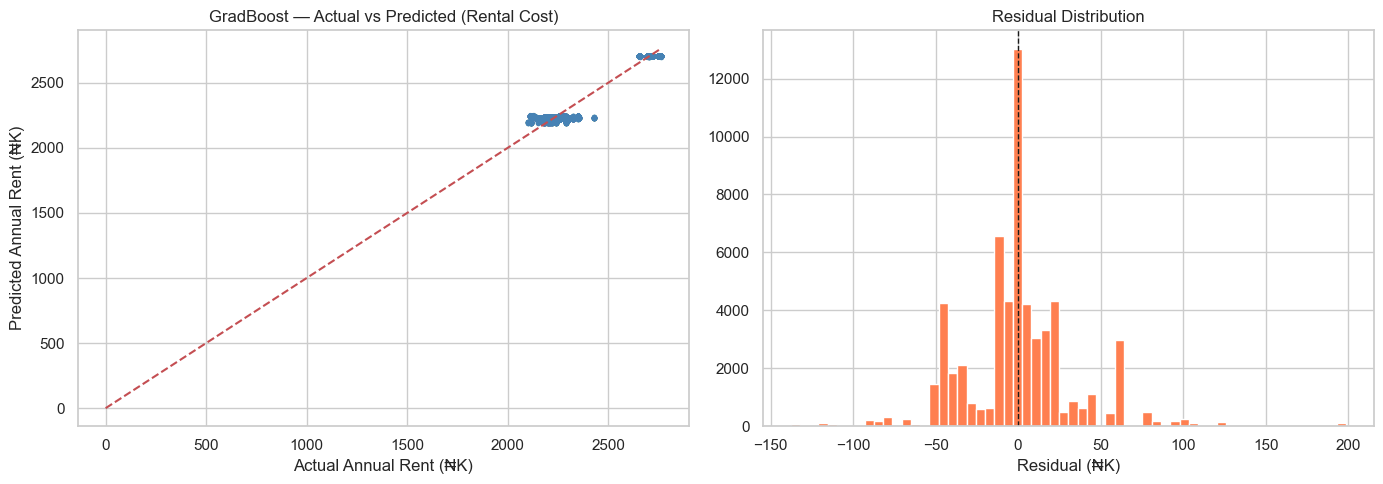

In [ ]:
best_reg_preds = best_reg_model.predict(X_reg_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_reg_test / 1_000, best_reg_preds / 1_000, alpha=0.2, s=8, color='steelblue')
lim = max(y_reg_test.max(), best_reg_preds.max()) / 1_000
axes[0].plot([0, lim], [0, lim], 'r--')
axes[0].set_xlabel('Actual Annual Rent (₦K)')
axes[0].set_ylabel('Predicted Annual Rent (₦K)')
axes[0].set_title(f'{best_reg_name} — Actual vs Predicted (Rental Cost)')

residuals = (y_reg_test.values - best_reg_preds) / 1_000
axes[1].hist(residuals, bins=60, color='coral', edgecolor='white')
axes[1].axvline(0, color='k', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual (₦K)')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()


### 6b. Classification Metrics

In [ ]:
type_class_names = encoders['property_type'].classes_.tolist()
tier_class_names = encoders['price_tier'].classes_.tolist()

# ── Task A: Property Type ──────────────────────────────────────────────────────
print('═' * 60)
print('TASK A — Property Type Classification (5 classes)')
print('═' * 60)
best_type_name = None
best_type_acc  = 0
for name, model in trained_type.items():
    preds = model.predict(X_clf_test)
    acc = accuracy_score(y_type_test, preds)
    print(f'\n── {name} — Accuracy: {acc:.4f} ──')
    print(classification_report(y_type_test, preds, target_names=type_class_names))
    if acc > best_type_acc:
        best_type_acc, best_type_name = acc, name

best_type_model = trained_type[best_type_name]
print(f'Best property-type model: {best_type_name} ({best_type_acc:.4f})')

# ── Task B: Price Tier ────────────────────────────────────────────────────────
print('\n' + '═' * 60)
print('TASK B — Price Tier Classification (Low / Mid / High)')
print('═' * 60)
best_tier_name = None
best_tier_acc  = 0
for name, model in trained_tier.items():
    preds = model.predict(X_clf_test)
    acc = accuracy_score(y_tier_test, preds)
    print(f'\n── {name} — Accuracy: {acc:.4f} ──')
    print(classification_report(y_tier_test, preds, target_names=tier_class_names))
    if acc > best_tier_acc:
        best_tier_acc, best_tier_name = acc, name

best_tier_model = trained_tier[best_tier_name]
print(f'Best price-tier model: {best_tier_name} ({best_tier_acc:.4f})')


════════════════════════════════════════════════════════════
TASK A — Property Type Classification (5 classes)
════════════════════════════════════════════════════════════

── XGBoost — Accuracy: 1.0000 ──
               precision    recall  f1-score   support

     bungalow       1.00      1.00      1.00      2966
     detached       1.00      1.00      1.00      8976
         flat       1.00      1.00      1.00     21051
semi_detached       1.00      1.00      1.00     12032
      terrace       1.00      1.00      1.00     14975

     accuracy                           1.00     60000
    macro avg       1.00      1.00      1.00     60000
 weighted avg       1.00      1.00      1.00     60000


── LightGBM — Accuracy: 1.0000 ──
               precision    recall  f1-score   support

     bungalow       1.00      1.00      1.00      2966
     detached       1.00      1.00      1.00      8976
         flat       1.00      1.00      1.00     21051
semi_detached       1.00      1.00      

## 7. Feature Importance (SHAP)

=== SHAP — Rental Cost Regression ===
Features: location + neighbourhood amenities + electricity


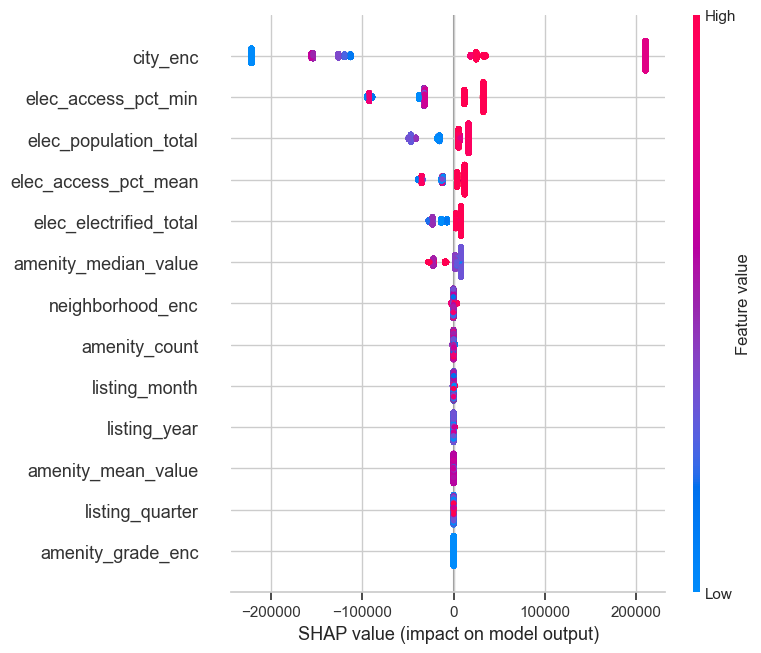

In [ ]:
print('=== SHAP — Rental Cost Regression ===')
print('Features: location + neighbourhood amenities + electricity')
explainer_reg = shap.TreeExplainer(best_reg_model)
shap_vals_reg = explainer_reg.shap_values(X_reg_test)
shap.summary_plot(shap_vals_reg, X_reg_test, feature_names=REG_FEATURES, show=True)


=== SHAP — Property Type Classification ===


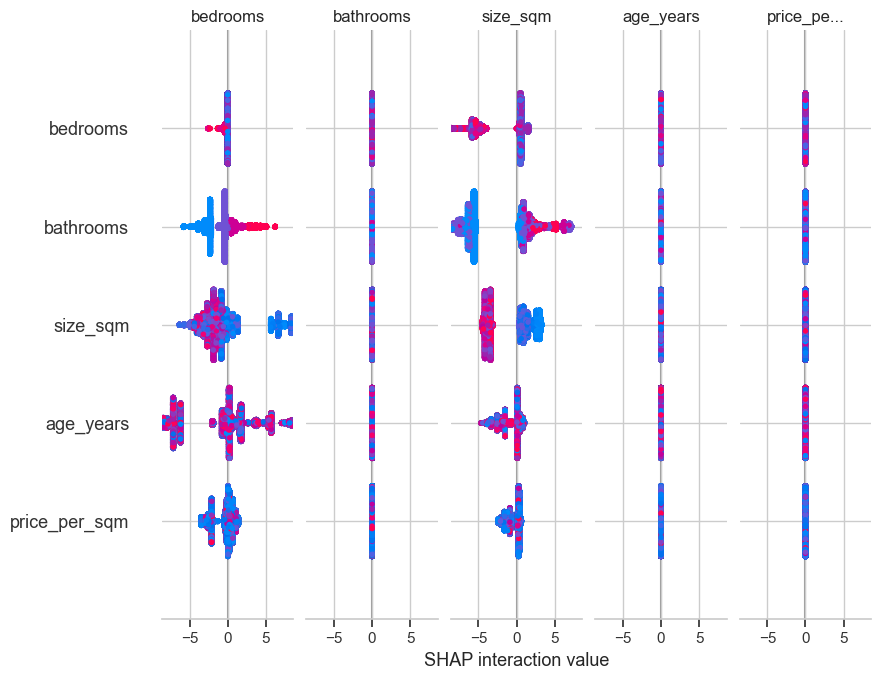

=== SHAP — Price Tier Classification ===


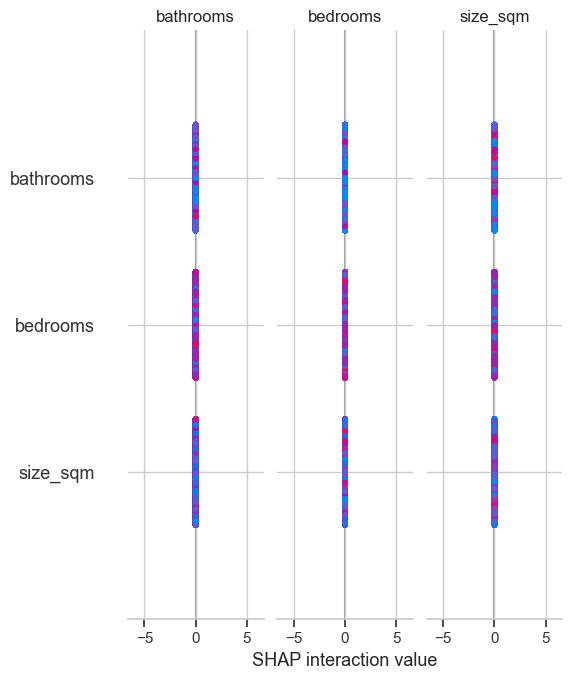

In [ ]:
print('=== SHAP — Property Type Classification ===')
explainer_type = shap.TreeExplainer(best_type_model)
shap_vals_type = explainer_type.shap_values(X_clf_test)
shap.summary_plot(shap_vals_type, X_clf_test, feature_names=CLF_FEATURES, show=True)

print('=== SHAP — Price Tier Classification ===')
explainer_tier = shap.TreeExplainer(best_tier_model)
shap_vals_tier = explainer_tier.shap_values(X_clf_test)
shap.summary_plot(shap_vals_tier, X_clf_test, feature_names=CLF_FEATURES, show=True)


## 8. Save Models

In [ ]:
reg_path  = f'../model/{best_reg_name.lower()}_rental_price_regressor.pkl'
type_path = f'../model/{best_type_name.lower()}_property_type_classifier.pkl'
tier_path = f'../model/{best_tier_name.lower()}_price_tier_classifier.pkl'

joblib.dump(best_reg_model,  reg_path)
joblib.dump(best_type_model, type_path)
joblib.dump(best_tier_model, tier_path)

print(f'Rental regression model saved : {reg_path}')
print(f'Property type model saved     : {type_path}')
print(f'Price tier model saved        : {tier_path}')
print(f'Label encoders saved          : ../model/label_encoders.pkl')

# ── Smoke-test: reload and predict on 3 test rows ─────────────────────────────
sample_reg = X_reg_test.iloc[:3]
sample_clf = X_clf_test.iloc[:3]

loaded_reg  = joblib.load(reg_path)
loaded_type = joblib.load(type_path)
loaded_tier = joblib.load(tier_path)

print('\nSample annual rent predictions (₦):',
      [f'{p:,.0f}' for p in loaded_reg.predict(sample_reg)])
print('Sample property type predictions :',
      encoders['property_type'].inverse_transform(loaded_type.predict(sample_clf)).tolist())
print('Sample price tier predictions    :',
      encoders['price_tier'].inverse_transform(loaded_tier.predict(sample_clf)).tolist())


Rental regression model saved : ../model/gradboost_rental_price_regressor.pkl
Property type model saved     : ../model/xgboost_property_type_classifier.pkl
Price tier model saved        : ../model/xgboost_price_tier_classifier.pkl
Label encoders saved          : ../model/label_encoders.pkl

Sample annual rent predictions (₦): ['2,219,194', '2,232,549', '2,209,606']
Sample property type predictions : ['flat', 'detached', 'bungalow']
Sample price tier predictions    : ['Mid', 'Low', 'Low']
